In [4]:
!pip install xgboost
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 45.6 MB/s  0:00:00



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [101]:
import pandas as pd
import numpy as np

# 시각화 세트
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 학습용, 테스트용 데이터 분리하는 패키지
from sklearn.model_selection import train_test_split

# 데이터 전처리 및 성능 평가 도구 - 데이터 분할과 회귀 모델의 성능 지표($R^2$, $MSE$ 등)를 측정
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# 선형 회귀 계열 모델 (Linear, Ridge, Lasso) - 선형 회귀와 과적합 방지를 위한 규제 모델
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# 트리 기반 앙상블 모델 (Bagging & Boosting) - 랜덤 포레스트와 최신 부스팅 모델들
# 사이킷런 내장 모델
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# 별도 설치 모델 (Anaconda 환경이면 대부분 포함되어 있거나 pip install 필요)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 주피터 노트북 내 그래프 출력을 위한 설정
%matplotlib inline

# 런타임오류들은 안뜨게 해줌
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [102]:
train = pd.read_csv('train.csv')
last_test = pd.read_csv('test.csv')
train

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


- 데이터 클렌징 및 가공과 시각화

In [103]:
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour

X= train.drop(['datetime', 'count', 'casual', 'registered'], axis=1)
y= train['count']

# 타겟 값 로그 변환 (성능 향상을 위해 권장)
y = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [100]:
# <!-- * 캐글 자전거 대여 수요 예측 데이터 셋을 활용하여 선형회귀와 트리 기반 회귀의 성능 차이 비교
# - 데이터셋 : www.kaggle.com/c/bike-sharing-demand/data
# - 데이터 컬럼 설명
# # datetime : 날짜+시간
# # season : 1=봄, 2=여름,3=가을, 4=겨울
# # holiday : 1=토, 일, 휴일, 0=휴일이 아닌날
# # workingday : 1=주중, 0=주말 및 휴일
# # weather : 1=맑음, 2=안개, 3=가벼운 눈/비 4=심한 눈/비
# # temp : 온도
# # atemp : 체감온도
# # humidity : 습도
# # windspeed : 풍속
# # casual : 사전 등록하지 않은 대여횟수
# # registered : 사전 등록한 대여횟수
# # count : 대여 횟수

# - 데이터 클렌징 및 가공과 시각화
# - 선형회귀, 릿지, 라쏘 모델 성능 평가
# - 랜덤포레스트, GBM(Gradient Boosting Machine), XGBoost(eXtreme Gradient Boosting), LightGBM(Light Gradient Boosting Machine) 모델 성능 평가 -->

In [104]:
X

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour
0,1,0,0,1,9.84,14.395,81,0.0000,2011,1,1,0
1,1,0,0,1,9.02,13.635,80,0.0000,2011,1,1,1
2,1,0,0,1,9.02,13.635,80,0.0000,2011,1,1,2
3,1,0,0,1,9.84,14.395,75,0.0000,2011,1,1,3
4,1,0,0,1,9.84,14.395,75,0.0000,2011,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,4,0,1,1,15.58,19.695,50,26.0027,2012,12,19,19
10882,4,0,1,1,14.76,17.425,57,15.0013,2012,12,19,20
10883,4,0,1,1,13.94,15.910,61,15.0013,2012,12,19,21
10884,4,0,1,1,13.94,17.425,61,6.0032,2012,12,19,22


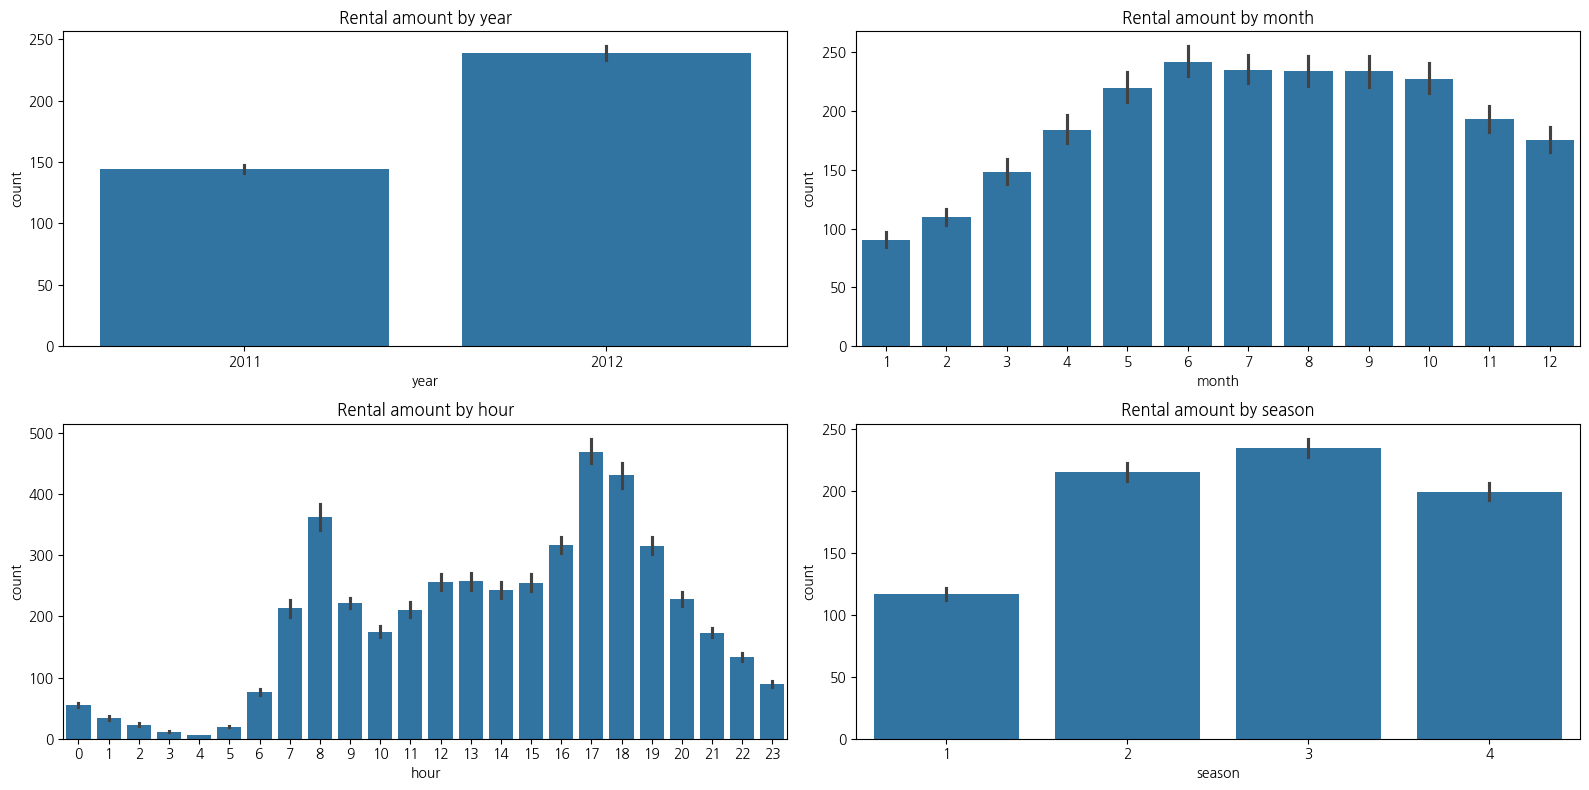

In [72]:
fig, axs = plt.subplots(figsize=(16, 8), ncols=2, nrows=2)

sns.barplot(x='year', y='count', data=train, ax=axs[0][0])
sns.barplot(x='month', y='count', data=train, ax=axs[0][1])
sns.barplot(x='hour', y='count', data=train, ax=axs[1][0])
sns.barplot(x='season', y='count', data=train, ax=axs[1][1])

axs[0][0].set(title="Rental amount by year")
axs[0][1].set(title="Rental amount by month")
axs[1][0].set(title="Rental amount by hour")
axs[1][1].set(title="Rental amount by season")
plt.tight_layout()
plt.show()

<Axes: xlabel='weather', ylabel='count'>

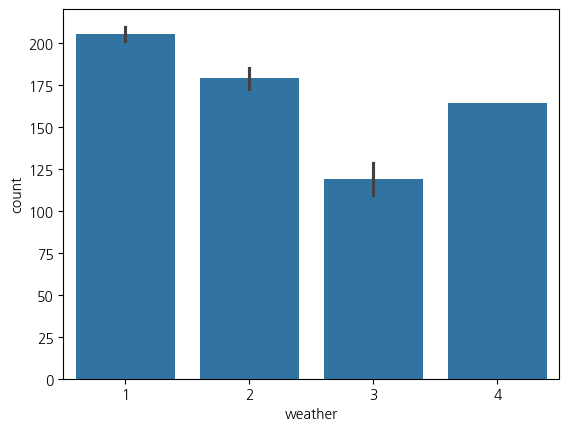

In [120]:
# sns.barplot은 해당 카테고리의 값들의 평균을 그려주는 그래프입니다.
# weather 1, 2, 3: 데이터가 수천 개씩 있으니, 그 수천 개의 count를 다 더해서 개수로 나눈 평균 대여량이 막대 높이가 됩니다.
# weather 4: 데이터가 딱 1개뿐이죠? 그 1개의 값이 만약 164라면, 평균도 그냥 164 / 1 = 164가 됩니다.
sns.barplot(x='weather', y='count', data=train)

In [118]:
train['weather'].value_counts()

weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

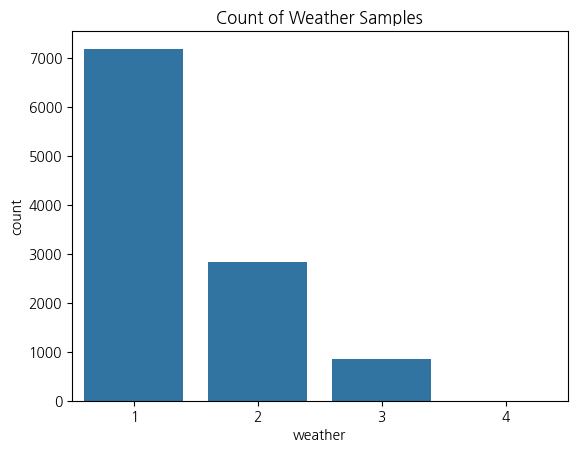

In [119]:
# 날씨별 데이터가 몇 건 있는지(빈도) 확인
sns.countplot(x='weather', data=train)
plt.title('Count of Weather Samples')
plt.show()

- 선형회귀, 릿지, 라쏘 모델 성능 평가

In [105]:
# 1. 일반 선형 회귀
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
lr_preds = lr_reg.predict(X_test)

# 2. 릿지 회귀 (alpha는 규제 강도, 클수록 규제가 강함)
ridge_reg = Ridge(alpha=10)
ridge_reg.fit(X_train, y_train)
ridge_preds = ridge_reg.predict(X_test)

# 3. 라쏘 회귀
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_train, y_train)
lasso_preds = lasso_reg.predict(X_test)

In [106]:
def get_rmse_r2(model_name, y_test, pred):
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)
    print(f'[{model_name}] RMSE: {rmse:.3f}, R2: {r2:.3f}')

# 각 모델 평가하기
get_rmse_r2('LinearRegression', y_test, lr_preds)
get_rmse_r2('Ridge (alpha=10)', y_test, ridge_preds)
get_rmse_r2('Lasso (alpha=0.1)', y_test, lasso_preds)

[LinearRegression] RMSE: 1.026, R2: 0.489
[Ridge (alpha=10)] RMSE: 1.026, R2: 0.489
[Lasso (alpha=0.1)] RMSE: 1.043, R2: 0.471


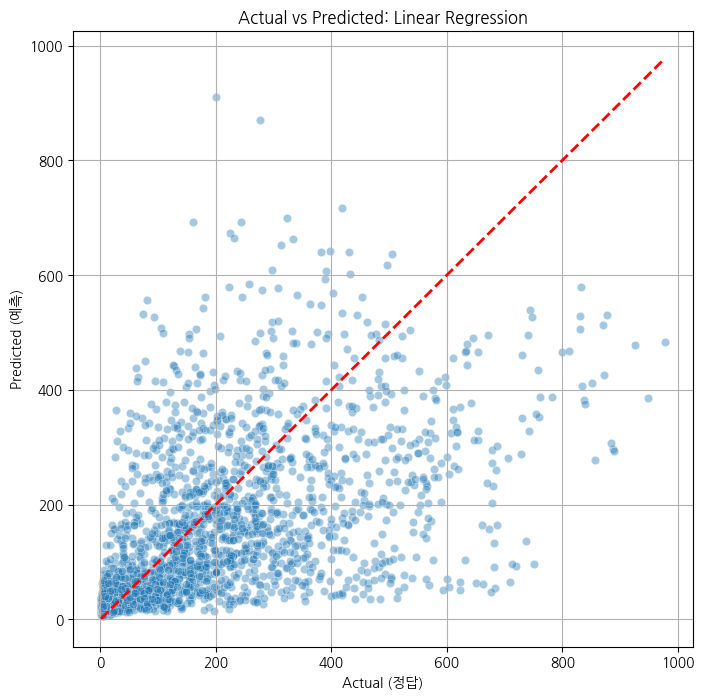

In [107]:
# 1. 예측값 복원 (로그 변환을 했다면 필수)
y_test_exp = np.expm1(y_test)
lr_preds_exp = np.expm1(lr_preds)

plt.figure(figsize=(8, 8))

# 2. 실제값 vs 예측값 산점도
sns.scatterplot(x=y_test_exp, y=lr_preds_exp, alpha=0.4)

# 3. 기준선 (빨간 점선: 예측이 완벽하면 점들이 이 선 위에 있음)
# 정답의 최소값부터 최대값까지 직선을 긋습니다.
plt.plot([y_test_exp.min(), y_test_exp.max()], [y_test_exp.min(), y_test_exp.max()], 
         color='red', linestyle='--', linewidth=2)

plt.xlabel('Actual (정답)')
plt.ylabel('Predicted (예측)')
plt.title('Actual vs Predicted: Linear Regression')
plt.grid(True)
plt.show()

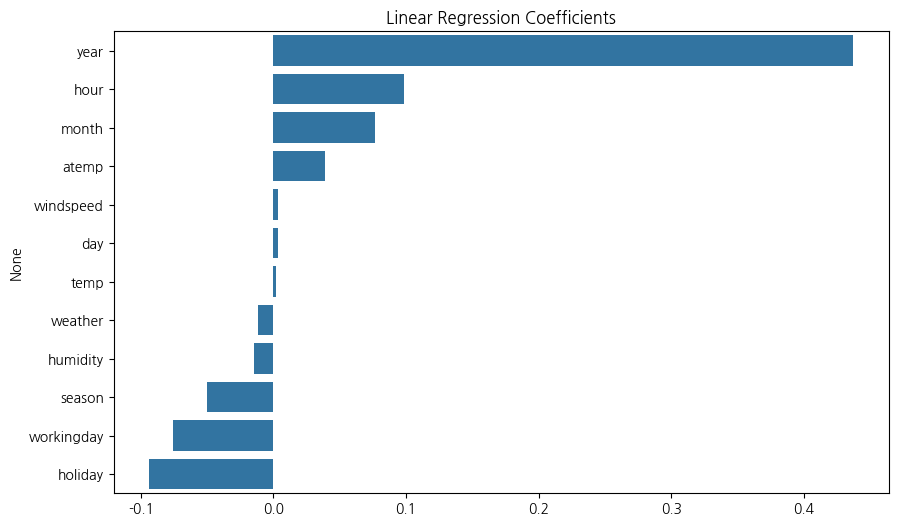

In [108]:
# 피처별 회귀 계수 시각화
coef = pd.Series(lr_reg.coef_, index=X_train.columns)
coef_sort = coef.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=coef_sort.values, y=coef_sort.index)
plt.title('Linear Regression Coefficients')
plt.show()

- 랜덤포레스트, GBM(Gradient Boosting Machine), XGBoost(eXtreme Gradient Boosting), LightGBM(Light Gradient Boosting Machine) 모델 성능 평가

In [109]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 1. 모델 준비
rf_reg = RandomForestRegressor(n_estimators=500, random_state=42)
xgb_reg = XGBRegressor(n_estimators=500, learning_rate=0.1, random_state=42)
lgbm_reg = LGBMRegressor(n_estimators=500, learning_rate=0.1, random_state=42)

# 2. 학습 (y_train이 로그 변환된 상태라고 가정)
rf_reg.fit(X_train, y_train)
xgb_reg.fit(X_train, y_train)
lgbm_reg.fit(X_train, y_train)

# 3. 예측 및 복원 (exp)
models = [rf_reg, xgb_reg, lgbm_reg]
for model in models:
    preds = model.predict(X_test)
    # 로그 복원 후 성능 평가
    get_rmse_r2(model.__class__.__name__, np.expm1(y_test), np.expm1(preds))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000186 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 287
[LightGBM] [Info] Number of data points in the train set: 8708, number of used features: 12
[LightGBM] [Info] Start training from score 4.593780
[RandomForestRegressor] RMSE: 43.707, R2: 0.942
[XGBRegressor] RMSE: 40.561, R2: 0.950
[LGBMRegressor] RMSE: 40.671, R2: 0.950


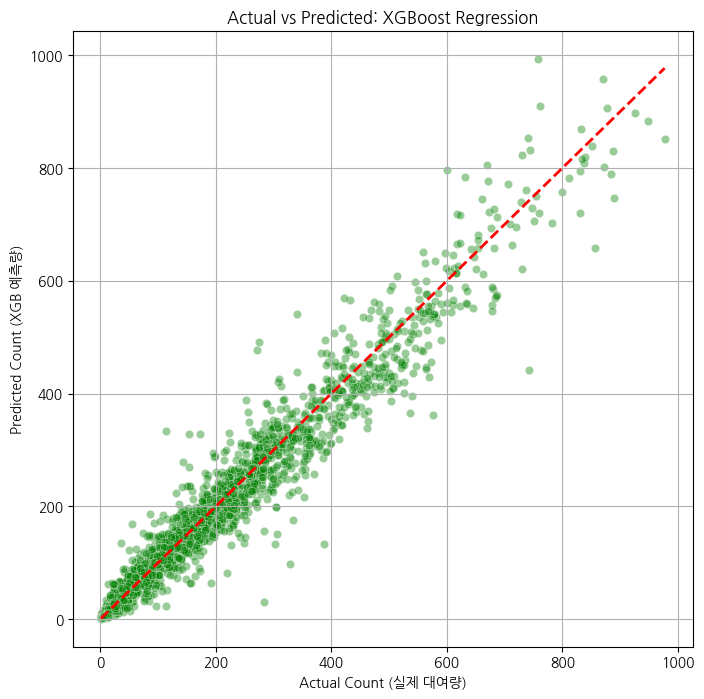

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. XGBoost 모델로 예측 (이미 학습된 xgb_reg 사용)
xgb_preds = xgb_reg.predict(X_test)

# 2. 로그 변환된 값을 원래 단위(대여량)로 복원
y_test_exp = np.expm1(y_test)
xgb_preds_exp = np.expm1(xgb_preds)

plt.figure(figsize=(8, 8))

# 3. 산점도 그리기 (실제값 vs 예측값)
sns.scatterplot(x=y_test_exp, y=xgb_preds_exp, alpha=0.4, color='green')

# 4. 기준선 (정답 선)
plt.plot([y_test_exp.min(), y_test_exp.max()], [y_test_exp.min(), y_test_exp.max()], 
         color='red', linestyle='--', linewidth=2)

plt.xlabel('Actual Count (실제 대여량)')
plt.ylabel('Predicted Count (XGB 예측량)')
plt.title('Actual vs Predicted: XGBoost Regression')
plt.grid(True)
plt.show()

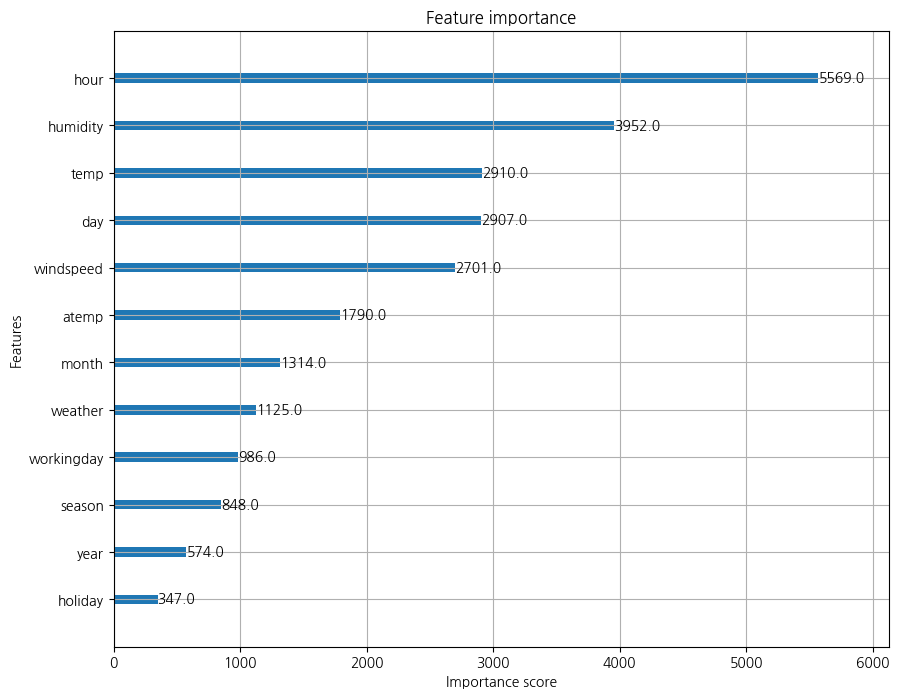

In [111]:
# XGBoost의 피처 중요도 시각화
from xgboost import plot_importance

fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(xgb_reg, ax=ax)
plt.show()

In [112]:
def get_eval_scores(model_name, y_test, pred):
    # 1. 로그 변환된 값을 원래 스케일로 복원 (매우 중요!)
    y_test_exp = np.expm1(y_test)
    pred_exp = np.expm1(pred)
    
    # 2. 각 지표 계산
    mae = mean_absolute_error(y_test_exp, pred_exp)
    mse = mean_squared_error(y_test_exp, pred_exp)
    rmse = np.sqrt(mse)
    
    # 3. RMSLE 계산 (로그 오차의 제곱근)
    # 직접 계산하거나 log1p를 적용한 값의 RMSE와 같습니다.
    log_y = np.log1p(y_test_exp)
    log_pred = np.log1p(pred_exp)
    rmsle = np.sqrt(mean_squared_error(log_y, log_pred))
    
    # 4. R2 스코어
    r2 = r2_score(y_test_exp, pred_exp)
    
    print(f'##### {model_name} #####')
    print(f'MAE: {mae:.3f}, MSE: {mse:.3f}')
    print(f'RMSE: {rmse:.3f}, RMSLE: {rmsle:.3f}, R2: {r2:.3f}\n')

In [113]:
# 선형 회귀 모델들 평가
get_eval_scores('LinearRegression', y_test, lr_preds)
get_eval_scores('Ridge', y_test, ridge_preds)
get_eval_scores('Lasso', y_test, lasso_preds)

# 모델별로 예측값 생성
rf_preds = rf_reg.predict(X_test)
xgb_preds = xgb_reg.predict(X_test)
lgbm_preds = lgbm_reg.predict(X_test)

# 트리 기반 모델들 평가
get_eval_scores('RandomForest', y_test, rf_preds)
get_eval_scores('XGBoost', y_test, xgb_preds)
get_eval_scores('LightGBM', y_test, lgbm_preds)

##### LinearRegression #####
MAE: 108.217, MSE: 25809.992
RMSE: 160.655, RMSLE: 1.026, R2: 0.218

##### Ridge #####
MAE: 108.212, MSE: 25809.781
RMSE: 160.654, RMSLE: 1.026, R2: 0.218

##### Lasso #####
MAE: 110.442, MSE: 27262.788
RMSE: 165.114, RMSLE: 1.043, R2: 0.174

##### RandomForest #####
MAE: 27.012, MSE: 1910.308
RMSE: 43.707, RMSLE: 0.323, R2: 0.942

##### XGBoost #####
MAE: 25.565, MSE: 1645.217
RMSE: 40.561, RMSLE: 0.304, R2: 0.950

##### LightGBM #####
MAE: 25.386, MSE: 1654.114
RMSE: 40.671, RMSLE: 0.298, R2: 0.950



📊 회귀 모델 평가 지표 완벽 정리
1. MAE (Mean Absolute Error) : "평균 절대 오차"
수식: abs(실제값 - 예측값)의 평균

직관적 의미: "평균적으로 몇 대 정도 틀렸나?" (가장 정직한 지표)

특징: 모든 오차에 동일한 가중치를 줍니다. 10대 틀린 거나 100대 틀린 거나 그냥 틀린 만큼만 점수가 깎입니다.

2. MSE (Mean Squared Error) : "평균 제곱 오차"
수식: (실제값 - 예측값)^2의 평균

직관적 의미: "크게 틀린 놈에게 벌금을 세게 매기겠다!"

특징: 오차를 제곱하기 때문에, **튀는 값(Outlier)**이 있으면 숫자가 엄청나게 커집니다. (예: 10대 틀리면 벌점 100점, 100대 틀리면 벌점 10,000점!)

3. RMSE (Root Mean Squared Error) : "평균 제곱 오차의 제곱근"
수식: sqrt(MSE)

직관적 의미: "현실 세계의 단위로 다시 맞춘 오차"

특징: MSE는 단위가 제곱되어 너무 커지니까(대여량의 제곱?), 다시 루트를 씌워 실제 대여량 단위로 맞춘 것입니다. 가장 대중적으로 쓰이는 지표입니다.

4. RMSLE (Root Mean Squared Log Error) : "로그 평균 제곱 오차"
수식: 실제값과 예측값에 각각 log(1+x)를 한 뒤 RMSE 계산

직관적 의미: "비율적으로 얼마나 틀렸나?"

특징 (자전거 데이터의 핵심!): * 과소평가에 민감: 실제 100대인데 80대로 예측한 게, 1000대인데 980대로 예측한 것보다 더 큰 에러라고 판단합니다.

아웃라이어에 강함: 로그를 씌우면 10,000처럼 튀는 값도 9.2 정도로 작아져서 전체 점수가 왜곡되는 걸 막아줍니다.

5. R² (R-Squared) : "결정계수"
수식: 1 - (내 모델의 오차 / 평균값으로만 예측했을 때의 오차)

직관적 의미: "내 모델이 데이터의 변동성을 몇 %나 설명하나?" (수능 등급 같은 상대 평가)

특징: * 1에 가까울수록 "데이터의 패턴을 완벽히 이해함"

0에 가까울수록 "그냥 평균값만 말하는 사람 수준임"

사용자님의 선형회귀가 0.21이 나온 건, 자전거 대여량의 복잡한 변화 중 **21%**만 겨우 설명하고 있다는 뜻입니다.

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def get_eval_summary(model_name, y_test, pred):
    """
    회귀 모델의 주요 평가 지표를 출력하는 함수
    (로그 변환된 y_test와 pred를 입력받아 원본 스케일로 복원 후 계산)
    """
    # 1. 원본 스케일 복원 (로그 -> 실제 대여량)
    y_test_exp = np.expm1(y_test)
    pred_exp = np.expm1(pred)
    
    # 예측값이 음수일 경우 0으로 보정 (RMSLE 에러 방지)
    pred_exp[pred_exp < 0] = 0
    
    # 2. 지표 계산
    mae = mean_absolute_error(y_test_exp, pred_exp)
    mse = mean_squared_error(y_test_exp, pred_exp)
    rmse = np.sqrt(mse)
    
    # RMSLE 직접 계산
    log_y = np.log1p(y_test_exp)
    log_pred = np.log1p(pred_exp)
    rmsle = np.sqrt(mean_squared_error(log_y, log_pred))
    
    r2 = r2_score(y_test_exp, pred_exp)
    
    # 3. 출력
    print(f'[{model_name}] 평가 지표 요약')
    print(f'- MAE   (평균 오차)   : {mae:.3f} 대')
    print(f'- RMSE  (실제 단위)   : {rmse:.3f} 대')
    print(f'- RMSLE (로그 오차)   : {rmsle:.3f}')
    print(f'- R2    (설명력/정확도): {r2:.3f} (1에 가까울수록 좋음)')
    print('-' * 40)

# 사용 예시:
# get_eval_summary('XGBoost', y_test, xgb_preds)